# Notebook 1 — Exploratory Data Analysis

**DATA5322 — Statistical Machine Learning II**  
Seattle University, Spring 2026  
Team: Ruman Sidhu, Paul Skentzos, Hamda Hassan

---

## Goals
- Load and inspect all four datasets (BC-TCGA, GSE2034, GSE25066, Simulation)
- Confirm dimensions, data types, and assess missing values
- Visualize gene expression distributions and compare scales across datasets
- Decide which dataset to use for the main analysis and document the reasoning
- Apply preprocessing and save the cleaned matrix for downstream notebooks

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 12)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

DATA_DIR  = Path('../data')
PLOTS_DIR = Path('../plots')
PLOTS_DIR.mkdir(exist_ok=True)

---
## 1. Load All Datasets

Each file is tab-separated.  
- Row 0 is the header: `Hybridization REF` followed by sample IDs.  
- Subsequent rows: gene name (index) followed by expression values.  
- We transpose immediately so the working convention is samples × genes.

In [13]:
def load_expression(path: Path) -> pd.DataFrame:
    """Load a tab-separated expression file and return a (samples x genes) DataFrame."""
    df = pd.read_csv(path, sep='\t', index_col=0)
    df.index.name = 'Gene'
    return df.T  # transpose: rows=samples, cols=genes

datasets = {
    'BC-TCGA Tumor':     load_expression(DATA_DIR / 'BC-TCGA'        / 'BC-TCGA-Tumor.txt'),
    'BC-TCGA Normal':    load_expression(DATA_DIR / 'BC-TCGA'        / 'BC-TCGA-Normal.txt'),
    'GSE2034 Tumor':     load_expression(DATA_DIR / 'GSE2034'        / 'GSE2034-Tumor.txt'),
    'GSE2034 Normal':    load_expression(DATA_DIR / 'GSE2034'        / 'GSE2034-Normal.txt'),
    'GSE25066 Tumor':    load_expression(DATA_DIR / 'GSE25066'       / 'GSE25066-Tumor.txt'),
    'GSE25066 Normal':   load_expression(DATA_DIR / 'GSE25066'       / 'GSE25066-Normal.txt'),
    'Simulation Tumor':  load_expression(DATA_DIR / 'Simulation-Data'/ 'Simulation-Data-Tumor.txt'),
    'Simulation Normal': load_expression(DATA_DIR / 'Simulation-Data'/ 'Simulation-Data-Normal.txt'),
}

print(f"{'Dataset':<25} {'Samples':>8} {'Genes':>8}")
print('-' * 44)
for name, df in datasets.items():
    print(f"{name:<25} {df.shape[0]:>8} {df.shape[1]:>8}")

Dataset                    Samples    Genes
--------------------------------------------
BC-TCGA Tumor                  529    17814
BC-TCGA Normal                  61    17814
GSE2034 Tumor                  179    12634
GSE2034 Normal                 107    12634
GSE25066 Tumor                 392    12634
GSE25066 Normal                100    12634
Simulation Tumor               100    10000
Simulation Normal              100    10000


---
## 2. Spot-Check the Primary Dataset

In [14]:
tcga = datasets['BC-TCGA Tumor']
print('Shape (samples x genes):', tcga.shape)
tcga.iloc[:5, :6]

Shape (samples x genes): (529, 17814)


Gene,ELMO2,CREB3L1,RPS11,PNMA1,MMP2,C10orf90
TCGA-AO-A03P-01A-11R-A00Z-07,1.2194,-0.1522,2.1934,-0.2188,-0.1487,-1.9550
TCGA-A8-A06T-01A-11R-A00Z-07,0.4303,0.4445,-0.1006,-0.1675,-0.2060,-2.0185
TCGA-A8-A07F-01A-11R-A00Z-07,0.4398,1.8822,0.0556,-0.0260,0.9702,-3.2575
TCGA-A8-A081-01A-11R-A00Z-07,1.2427,1.7810,0.2695,0.1497,-1.0732,-2.7407
TCGA-A8-A08C-01A-11R-A00Z-07,-0.2283,0.5335,0.7224,0.4275,-0.2837,-1.8480


---
## 3. Missing Value Assessment

The BC-TCGA Tumor file encodes some missing measurements as the literal string `null`
(not an empty cell). Pandas automatically reads this as `NaN`, so `isnull()` catches it correctly.

In [15]:
print(f"{'Dataset':<25} {'Missing cells':>15} {'% Missing':>12}")
print('-' * 54)
for name, df in datasets.items():
    total   = df.size
    missing = df.isnull().sum().sum()
    print(f"{name:<25} {missing:>15,} {missing/total*100:>11.4f}%")

Dataset                     Missing cells    % Missing
------------------------------------------------------
BC-TCGA Tumor                       1,497      0.0159%
BC-TCGA Normal                        198      0.0182%
GSE2034 Tumor                           0      0.0000%
GSE2034 Normal                          0      0.0000%
GSE25066 Tumor                          0      0.0000%
GSE25066 Normal                         0      0.0000%
Simulation Tumor                        0      0.0000%
Simulation Normal                       0      0.0000%


In [16]:
# Drill into the BC-TCGA Tumor nulls
tcga_missing       = tcga.isnull()
genes_with_nulls   = tcga_missing.any(axis=0).sum()
samples_with_nulls = tcga_missing.any(axis=1).sum()
total_nulls        = tcga_missing.sum().sum()

print(f'Total null values  : {total_nulls:,}  ({total_nulls / tcga.size * 100:.4f}% of all cells)')
print(f'Genes affected     : {genes_with_nulls:,} / {tcga.shape[1]:,} ({genes_with_nulls/tcga.shape[1]*100:.1f}%)')
print(f'Samples affected   : {samples_with_nulls:,} / {tcga.shape[0]:,} ({samples_with_nulls/tcga.shape[0]*100:.1f}%)')

null_per_gene   = tcga_missing.sum(axis=0)
null_per_sample = tcga_missing.sum(axis=1)

print('\nTop 10 genes by null count:')
print(null_per_gene[null_per_gene > 0].sort_values(ascending=False).head(10).to_string())
print('\nTop 10 samples by null count:')
print(null_per_sample[null_per_sample > 0].sort_values(ascending=False).head(10).to_string())

Total null values  : 1,497  (0.0159% of all cells)
Genes affected     : 487 / 17,814 (2.7%)
Samples affected   : 280 / 529 (52.9%)

Top 10 genes by null count:
Gene
LCE1B        16
LHX5         16
ADAM5P       14
LOC646982    14
CCDC140      13
OR4F15       13
RPTN         13
OR1J4        13
DEFB127      12
RPE65        12

Top 10 samples by null count:
TCGA-BH-A0HU-01A-11R-A034-07    57
TCGA-B6-A0IE-01A-11R-A034-07    43
TCGA-AR-A1AU-01A-11R-A12P-07    38
TCGA-BH-A0HQ-01A-11R-A034-07    36
TCGA-AO-A0J9-01A-11R-A034-07    32
TCGA-AN-A0FD-01A-11R-A034-07    26
TCGA-E2-A1B6-01A-31R-A12P-07    24
TCGA-BH-A0BF-01A-21R-A12P-07    24
TCGA-B6-A0IO-01A-11R-A034-07    24
TCGA-B6-A0I6-01A-11R-A034-07    22


---
## 4. Understanding the Missing Data

---

When we looked closely at the BC-TCGA dataset, we found that roughly 1,500 out of 9.4 million data
points were recorded as missing. That is less than 0.02% of the entire dataset, which is a very small
issue overall. But which data is missing turns out to be informative.

### What the numbers mean

Each number in this dataset represents how actively a particular gene was "switched on" in a
patient's tumor. Genes are the instructions inside every cell that tell it how to function. When a
gene is active, the cell is reading those instructions and producing proteins. When a gene is
inactive, nothing is being produced, and the activity level is effectively zero.

The measurement technology used here, called a microarray, works a bit like a very sensitive
listening device. It picks up the signal from active genes. When a gene is completely inactive in a
sample, there is no signal to detect, and the equipment records the result as missing rather than
zero. This is because it cannot tell the difference between "this gene is truly silent" and "something went
wrong with this measurement.".

### Which genes are affected and why it makes sense

Looking at the list of genes with missing values, a clear pattern emerges:

| Gene type | Examples | Why they are inactive in breast tumors |
|-----------|----------|----------------------------------------|
| **Smell receptors** | OR4F15, OR1J4, OR10AG1 | These genes help detect odors. They are active in nasal tissue, not in the breast. |
| **Taste receptors** | TAS2R42, TAS2R38 | These help sense bitter tastes. Again, irrelevant to breast tissue. |
| **Reproductive genes** | SRY, LHX5 | SRY is the gene that triggers male development. It has no activity in female breast tissue. |
| **Antiviral signaling** | IFNA7, IFNW1, IFNA10 | A subgroup of immune genes that respond to specific viral infections. They are not routinely active in breast tumors. |

These are genes that simply have no business being active in breast tissue. Their absence from the
measurements is not random data corruption. Instead, it is a biologically meaningful signal that these
particular cellular programs are turned off in this context.

### Why this is not a problem for our analysis

Our analysis is focused on finding patterns that *distinguish* one breast tumor from another. A gene
that is inactive in every single tumor carries no information about what makes tumors different and it
looks the same across everyone. Our preprocessing step ranks all 17,814 genes by how much their
activity varies across the 529 patients, and keeps only the top 5,000 most variable genes.
Genes that are consistently silent will land at the very bottom of that ranking and will be filtered
out automatically, taking most or all of the missing values with them.

Any genes with missing values that do survive this filter will have their null entries replaced with
the average value observed for that gene across the other patients, which is a standard and conservative
approach that avoids discarding useful data.

### A connection to one of our methods

This is also the real-world motivation for Notebook 3 (Matrix Completion). We are starting from a dataset that genuinely has missing entries, where
the missingness has a plausible biological explanation. Matrix completion asks: given the rich
structure of the rest of the data, can a mathematical model predict what a missing value *should*
have been? For these silent genes, the likely answer is: close to zero, consistent with other
patients where that gene was also near-silent.

---
## 5. Expression Value Distributions

Comparing the value scales across datasets helps us understand whether they are directly comparable
or require batch correction before combining.

In [17]:
# Summary statistics per dataset
summary_rows = []
for name, df in datasets.items():
    vals = df.values.ravel()
    vals = vals[~np.isnan(vals)]
    summary_rows.append({
        'Dataset': name,
        'Min':     vals.min(),
        'Median':  np.median(vals),
        'Mean':    vals.mean(),
        'Max':     vals.max(),
        'Std Dev': vals.std(),
    })

pd.DataFrame(summary_rows).set_index('Dataset').round(3)

,Min,Median,Mean,Max,Std Dev
Dataset,,,,,
BC-TCGA Tumor,-11.7850,0.0220,0.0020,14.2070,1.3370
BC-TCGA Normal,-9.8860,-0.0120,0.0160,11.0560,1.4300
GSE2034 Tumor,-10.9650,0.1190,-0.0110,8.7130,2.2560
GSE2034 Normal,-10.3990,0.0930,-0.0360,8.6350,2.2740
GSE25066 Tumor,-5.0070,8.1930,8.0450,19.3970,2.1300
GSE25066 Normal,-2.2890,8.1880,8.0530,20.8540,2.1180
Simulation Tumor,-0.5230,-0.0000,-0.0000,0.4800,0.1000
Simulation Normal,-0.5050,0.0000,0.0000,0.4740,0.1000


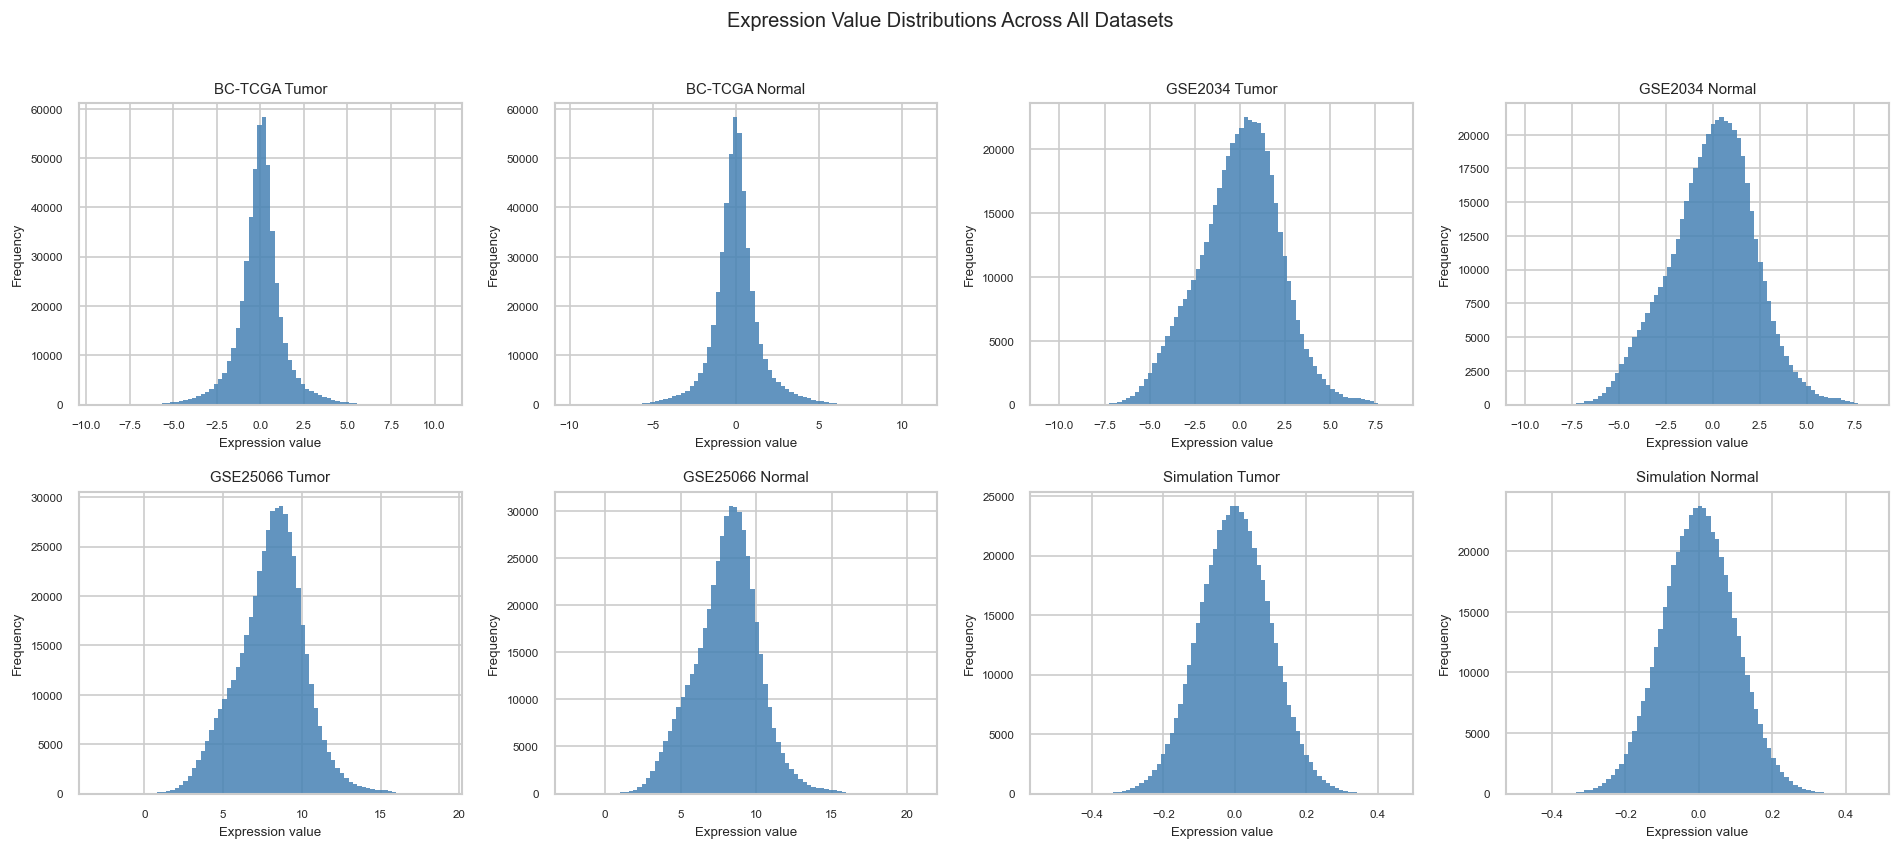

In [18]:
# Distribution histograms — one panel per dataset
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=False)
axes = axes.ravel()

for ax, (name, df) in zip(axes, datasets.items()):
    vals   = df.values.ravel()
    vals   = vals[~np.isnan(vals)]          # drop NaN before sampling
    rng    = np.random.default_rng(0)
    sample = rng.choice(vals, size=min(500_000, len(vals)), replace=False)
    ax.hist(sample, bins=80, color='steelblue', edgecolor='none', alpha=0.85)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Expression value', fontsize=8)
    ax.set_ylabel('Frequency', fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle('Expression Value Distributions Across All Datasets', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_distributions.png', bbox_inches='tight')
plt.show()

---
## 6. Per-Sample Boxplots (BC-TCGA Tumor)

Checking whether individual samples are roughly comparable in their expression distributions, which is a basic quality check before PCA and clustering.

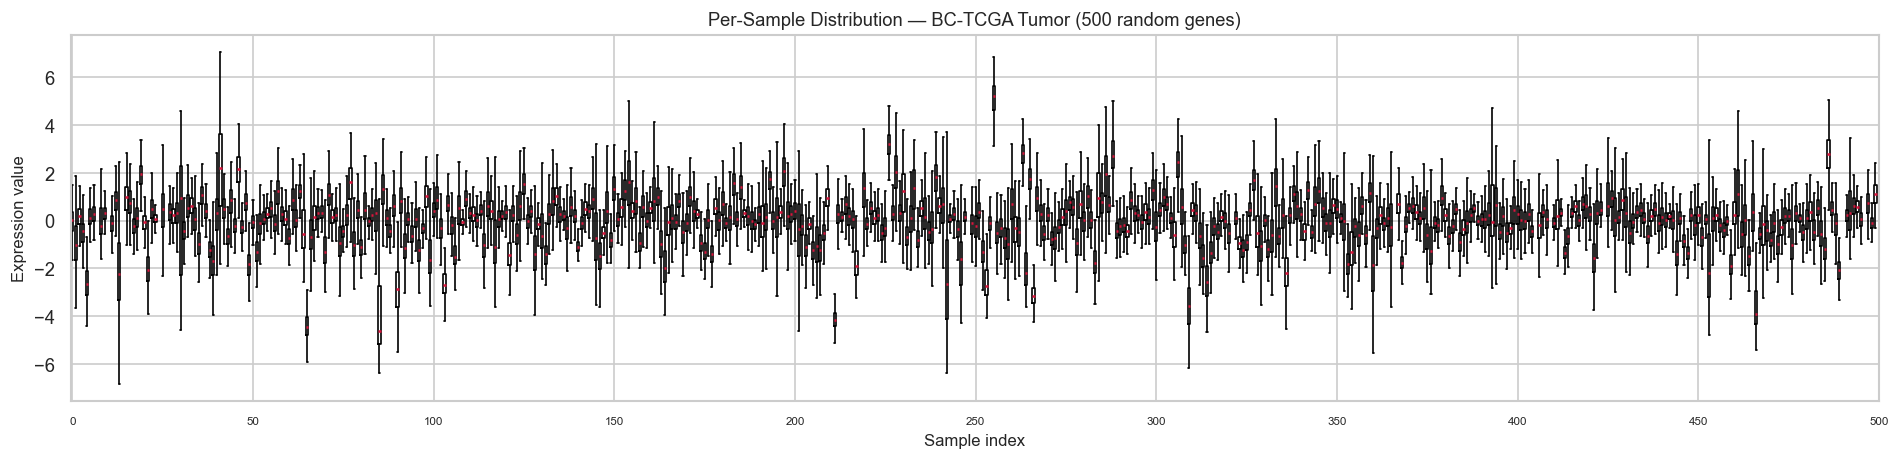

In [19]:
# Subsample genes for plotting speed
rng      = np.random.default_rng(1)
gene_idx = rng.choice(tcga.shape[1], size=min(500, tcga.shape[1]), replace=False)
plot_df  = tcga.iloc[:, gene_idx]

fig, ax = plt.subplots(figsize=(16, 4))
ax.boxplot(plot_df.values, notch=False, sym='', widths=0.6,
           medianprops=dict(color='crimson', linewidth=1.5))
ax.set_xlabel('Sample index', fontsize=10)
ax.set_ylabel('Expression value', fontsize=10)
ax.set_title('Per-Sample Distribution — BC-TCGA Tumor (500 random genes)', fontsize=11)
tick_pos  = list(range(1, tcga.shape[0] + 1, 50))
tick_labs = [str(i - 1) for i in tick_pos]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labs, fontsize=7)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_per_sample_boxplot.png', bbox_inches='tight')
plt.show()

---
## 7. Gene-Level Variance Distribution

Most genes show very little variation across samples. For PCA and clustering, retaining only the
top high-variance genes is standard practice in that it reduces noise and computation time without
losing information that is relevant to patient differences.

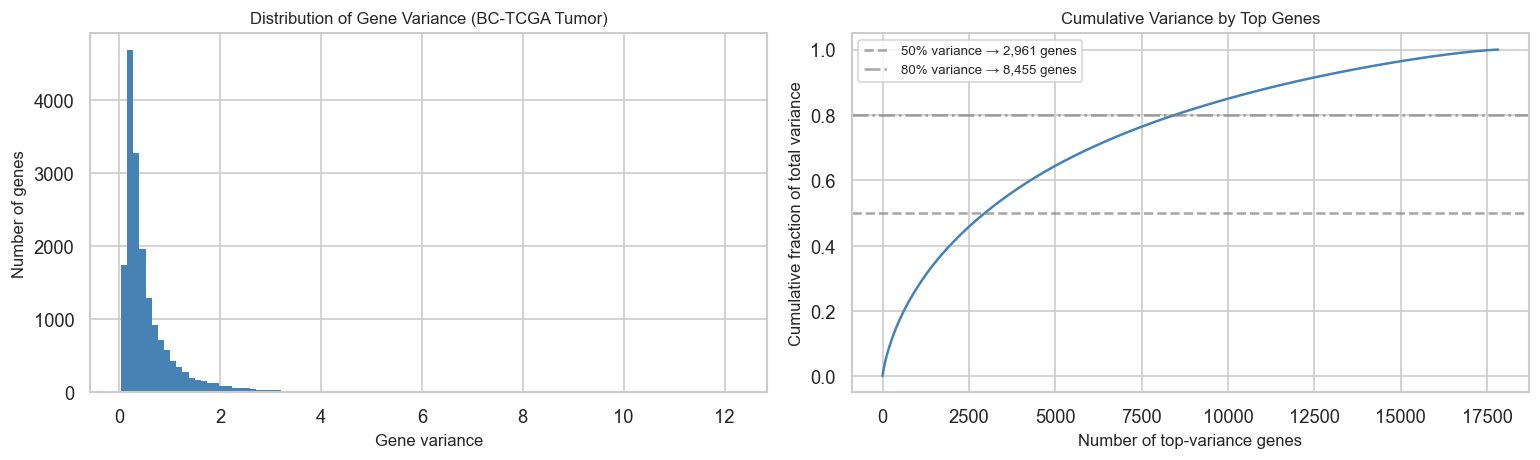

10% of total variance captured by top 225 genes (1.3% of all genes)
25% of total variance captured by top 875 genes (4.9% of all genes)
50% of total variance captured by top 2,961 genes (16.6% of all genes)
80% of total variance captured by top 8,455 genes (47.5% of all genes)
90% of total variance captured by top 11,865 genes (66.6% of all genes)


In [20]:
# pandas .var() skips NaN by default, so this is safe with the nulls present
gene_var = tcga.var(axis=0).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(gene_var.values, bins=100, color='steelblue', edgecolor='none')
axes[0].set_xlabel('Gene variance', fontsize=10)
axes[0].set_ylabel('Number of genes', fontsize=10)
axes[0].set_title('Distribution of Gene Variance (BC-TCGA Tumor)', fontsize=10)

cum_var = gene_var.cumsum() / gene_var.sum()
axes[1].plot(range(1, len(cum_var) + 1), cum_var.values, lw=1.5, color='steelblue')
for thresh, ls in [(0.50, '--'), (0.80, '-.')] :
    n_genes = (cum_var <= thresh).sum() + 1
    axes[1].axhline(thresh, color='gray', linestyle=ls, alpha=0.7,
                    label=f'{int(thresh*100)}% variance → {n_genes:,} genes')
axes[1].set_xlabel('Number of top-variance genes', fontsize=10)
axes[1].set_ylabel('Cumulative fraction of total variance', fontsize=10)
axes[1].set_title('Cumulative Variance by Top Genes', fontsize=10)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_gene_variance.png', bbox_inches='tight')
plt.show()

for pct in [10, 25, 50, 80, 90]:
    n = (cum_var <= pct / 100).sum() + 1
    print(f'{pct}% of total variance captured by top {n:,} genes ({n/len(gene_var)*100:.1f}% of all genes)')

---
## 8. Dataset Selection & Preprocessing

**Primary dataset chosen: BC-TCGA Tumor**
- Largest tumor cohort: 529 samples
- Most genes: 17,814
- Values are already log2 expression ratios, centered near 0, thus no log transform needed
- 1,497 `null` values (0.016%) across 487 genes, which is handled below

**Preprocessing pipeline:**
1. Keep only the top 5,000 highest-variance genes. Most null-affected genes are low-variance and will be dropped by this filter
2. **Mean-impute** any NaN values that survive the filter (per gene, using the observed sample mean)
3. **Standardize** each gene to zero mean and unit variance, which is required so that PCA and distance-based clustering treat all genes equally regardless of their original scale

In [21]:
from sklearn.preprocessing import StandardScaler

N_TOP_GENES = 5000

# Step 1: select top-variance genes
top_genes     = gene_var.index[:N_TOP_GENES]
tcga_filtered = tcga[top_genes].copy()

# Step 2: report remaining NaN after the variance filter
remaining_nulls = tcga_filtered.isnull().sum().sum()
null_genes_left = tcga_filtered.isnull().any(axis=0).sum()
print(f'NaN values remaining after gene filter : {remaining_nulls} (across {null_genes_left} genes)')

# Step 3: mean-impute any remaining NaN (per gene)
if remaining_nulls > 0:
    tcga_filtered = tcga_filtered.fillna(tcga_filtered.mean(axis=0))
    print(f'After imputation — remaining NaN       : {tcga_filtered.isnull().sum().sum()}')

print(f'\nShape after filter + imputation        : {tcga_filtered.shape}  (samples x genes)')

# Step 4: standardize
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(tcga_filtered)
print(f'Post-scaling mean                      : {X_scaled.mean():.6f}  (should be ~0)')
print(f'Post-scaling std                       : {X_scaled.std():.6f}   (should be ~1)')

NaN values remaining after gene filter : 716 (across 162 genes)
After imputation — remaining NaN       : 0

Shape after filter + imputation        : (529, 5000)  (samples x genes)
Post-scaling mean                      : 0.000000  (should be ~0)
Post-scaling std                       : 1.000000   (should be ~1)


---
## 9. Save Preprocessed Matrix

In [22]:
np.save(DATA_DIR / 'X_preprocessed.npy', X_scaled)
pd.Series(top_genes,             name='Gene'    ).to_csv(DATA_DIR / 'top_genes.csv',   index=False)
pd.Series(tcga_filtered.index,   name='SampleID').to_csv(DATA_DIR / 'sample_ids.csv',  index=False)

print('Saved:')
print(f'  data/X_preprocessed.npy  — shape {X_scaled.shape}')
print(f'  data/top_genes.csv       — {len(top_genes)} gene names')
print(f'  data/sample_ids.csv      — {len(tcga_filtered.index)} sample IDs')

Saved:
  data/X_preprocessed.npy  — shape (529, 5000)
  data/top_genes.csv       — 5000 gene names
  data/sample_ids.csv      — 529 sample IDs


---
## 10. Summary

| Property | Value |
|---|---|
| Primary dataset | BC-TCGA Tumor |
| Samples | 529 |
| Genes (raw) | 17,814 |
| Genes (after top-variance filter) | 5,000 |
| Missing values (raw) | 1,497 `null` strings (0.016%) across 487 genes |
| Missing values (after gene filter) | Reported at runtime — expected ~0 or very few |
| Imputation | Per-gene mean, applied to any NaN surviving the filter |
| Pre-existing normalization | Log2 expression ratios, already centered near 0 |
| Full preprocessing pipeline | Variance filter → mean imputation → StandardScaler |
| Output file | `data/X_preprocessed.npy` (529 × 5,000) |

**Notes on other datasets:**
- BC-TCGA Normal (61 samples): fully clean, no missing values
- GSE2034 and GSE25066: fully clean, but use different expression scales. By combining with TCGA we would require batch correction (e.g., ComBat)
- Simulation data: synthetic with a very small tumor/normal signal, which is useful for testing method behavior, not for biological conclusions